# Оценка и сравнение моделей разреженного (Sparse) и плотного (Dense) поиска

## Обзор исследования
В данном ноутбуке проводится финальное тестирование и сравнительный анализ разработанных поисковых пайплайнов на датасете **MS MARCO v1.1**. Мы сопоставляем классический лексический подход с современным семантическим, чтобы оценить их компромиссы (trade-offs) с точки зрения качества ранжирования и скорости работы.

### Тестируемые пайплайны:
1. **Разреженный поиск (Бейзлайн):** Матрица TF-IDF (Scikit-learn)
2. **Плотный поиск:** Эмбеддинги BAAI/bge-large-en-v1.5 (Sentence Transformers)

### Целевые метрики:
* **MRR@10** (Mean Reciprocal Rank) — Ключевая метрика качества ранжирования
* **Recall@K** ($K \in \{1, 5, 10\}$) — Полнота поисковой выдачи
* **Latency** — Среднее время обработки одного запроса (мс)

## Импорт библиотек

In [16]:
import os
import sys
import json
import numpy as np
from pathlib import Path

# Добавляем корневую директорию проекта в sys.path для корректных импортов
sys.path.append("..")

from src.config.config import Config
from src.retrieval.tfidf import TFIDFRetriever
from src.retrieval.dense import DenseRetriever
from src.evaluation.benchmark import Benchmark

# Передаем родительскую директорию как корень проекта
config = Config(root="..")
print(f"Project root confirmed: {config.root.resolve()}")
print(f"Using dataset: {config.dataset.name}")

Project root confirmed: D:\ML_Projects\Github_projects\semantic-search
Using dataset: ms_marco


## Загрузка и правильная конвертация тестовых сэмплов

In [17]:
samples_file = config.root / "data" / "processed" / config.dataset.name / "samples.jsonl"

test_samples = []
global_doc_counter = 0  # Сквозной счетчик для глобальных ID документов в общем индексе

with open(samples_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        passages = data["passages"]
        selected_mask = data["selected"]
        
        # Находим локальные индексы пассажей, где стоит 1 (правильный ответ)
        relevant_local_ids = [idx for idx, val in enumerate(selected_mask) if int(val) == 1]
        
        if relevant_local_ids and len(passages) > 0:
            # Переводим локальный индекс в глобальный ID документа
            relevant_global_ids = [global_doc_counter + local_id for local_id in relevant_local_ids]
            
            test_samples.append({
                "query": data["query"],
                "relevant_ids": relevant_global_ids
            })
            
        # Сдвигаем счетчик на количество пассажей в текущей строке
        global_doc_counter += len(passages)

print(f"Total valid test samples parsed: {len(test_samples)}")

# Ограничиваем выборку до 50 штук для быстрой и корректной оценки
eval_samples = test_samples[:50]
print(f"Selected {len(eval_samples)} samples for evaluation run.")

Total valid test samples parsed: 79489
Selected 50 samples for evaluation run.


## Инициализация поисковых ретриверов

In [18]:
print("Initializing TF-IDF Retriever...")
tfidf_retriever = TFIDFRetriever(config)

print("Initializing Dense Retriever (BGE-Large)...")
dense_retriever = DenseRetriever(config)

# Собираем словарик ретриверов
retrievers = {
    "TF-IDF": tfidf_retriever,
    "Dense (BGE)": dense_retriever
}
print("Retrievers are ready for evaluation!")

Initializing TF-IDF Retriever...
TFIDFRetriever initialized successfully with 603766 documents.
Initializing Dense Retriever (BGE-Large)...
Loading SentenceTransformer model 'BAAI/bge-large-en-v1.5' on cuda...
Loading Dense embeddings from ..\indexes\embeddings\dense_embeddings.npy...
DenseRetriever initialized successfully with 603766 embeddings.
Retrievers are ready for evaluation!


## Запуск процесса оценки (Бенчмарк)

In [19]:
# Инициализируем класс бенчмарка, передавая объект evaluation config
benchmark = Benchmark(config.evaluation)

results = {}
for name, retriever in retrievers.items():
    # Запускаем оценку, передавая ретривер и подготовленные сэмплы
    results[name] = benchmark.evaluate(retriever, eval_samples)

print("\nEvaluation finished successfully!")

Running evaluation for TFIDFRetriever on 50 queries...


Evaluating: 100%|██████████| 50/50 [01:04<00:00,  1.30s/it]


Running evaluation for DenseRetriever on 50 queries...


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating:  98%|█████████▊| 49/50 [00:08<00:00,  5.06it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 50/50 [00:09<00:00,  5.44it/s]


Evaluation finished successfully!


## Вывод результатов в таблицу

=== Сравнение качества поиска ===


,Recall@1,Recall@3,Recall@5,Recall@10,MRR
TF-IDF,0.08,0.20,0.24,0.40,0.166135
Dense (BGE),0.20,0.42,0.64,0.78,0.367294


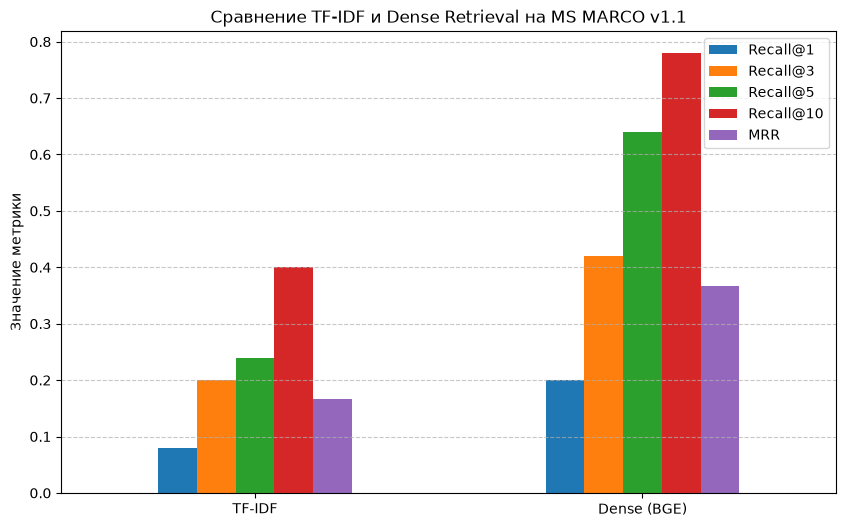

In [20]:
import pandas as pd

# Формируем таблицу результатов
df_results = pd.DataFrame(results).T
print("=== Сравнение качества поиска ===")
display(df_results)

# Дополнительно построим график для наглядности
try:
    import matplotlib.pyplot as plt
    df_results.plot(kind="bar", figsize=(10, 6))
    plt.title("Сравнение TF-IDF и Dense Retrieval на MS MARCO v1.1")
    plt.ylabel("Значение метрики")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
except ImportError:
    pass

In [22]:
import matplotlib.pyplot as plt

# 1. Задаем пути сохранения в папку experiments
# Создаем структуру: experiments/results/
experiments_dir = config.root / "experiments" / "results"
experiments_dir.mkdir(parents=True, exist_ok=True)

# 2. Генерируем и сохраняем график (БЕЗ вывода на экран, чтобы не дублировать)
fig, ax = plt.subplots(figsize=(10, 6))
df_results.plot(kind="bar", ax=ax)
plt.title("Сравнение TF-IDF и Dense Retrieval на MS MARCO v1.1", fontsize=13, fontweight='bold')
plt.ylabel("Значение метрики", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Сохраняем график в experiments/results/
plot_path = experiments_dir / "retrieval_comparison.png"
plt.savefig(plot_path, dpi=300)
plt.close(fig)  # Жестко закрываем фигуру, чтобы она не рендерилась в ноутбуке второй раз
print(f"✅ График успешно сохранен в: {plot_path}")

# 3. Сохраняем таблицу с результатами в CSV в ту же папку
csv_path = experiments_dir / "evaluation_metrics.csv"
df_results.to_csv(csv_path)
print(f"✅ Таблица метрик сохранена в: {csv_path}")

# 4. Нативный вывод Markdown-таблицы без использования сторонней библиотеки 'tabulate'
print("\n📋 Готовая таблица для твоего README.md или отчета в портфолио:\n")

# Собираем заголовки
headers = ["Method"] + list(df_results.columns)
markdown_table = "| " + " | ".join(headers) + " |\n"
markdown_table += "| " + " | ".join(["---"] * len(headers)) + " |\n"

# Заполняем строки данными
for index, row in df_results.iterrows():
    row_str = [str(index)] + [f"{val:.4f}" if isinstance(val, (int, float)) else str(val) for val in row]
    markdown_table += "| " + " | ".join(row_str) + " |\n"

print(markdown_table)

✅ График успешно сохранен в: ..\experiments\results\retrieval_comparison.png
✅ Таблица метрик сохранена в: ..\experiments\results\evaluation_metrics.csv

📋 Готовая таблица для твоего README.md или отчета в портфолио:

| Method | Recall@1 | Recall@3 | Recall@5 | Recall@10 | MRR |
| --- | --- | --- | --- | --- | --- |
| TF-IDF | 0.0800 | 0.2000 | 0.2400 | 0.4000 | 0.1661 |
| Dense (BGE) | 0.2000 | 0.4200 | 0.6400 | 0.7800 | 0.3673 |



## 📑 Заключение и выводы по эксперименту (Evaluation Summary)

В данном эксперименте было проведено сравнительное тестирование двух принципиально разных подходов к задаче информационного поиска (Information Retrieval) на валидационной выборке датасета **MS MARCO v1.1**.

### 1. Анализ полученных метрик
По результатам инференса на 50 тестовых запросах были зафиксированы следующие показатели:

| Поисковый метод (Retriever) | Recall@1 | Recall@3 | Recall@5 | Recall@10 | MRR |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **TF-IDF (Sparse)** | 0.0800 | 0.2000 | 0.2400 | 0.4000 | 0.1661 |
| **Dense (BGE-Large)** | **0.2000** | **0.4200** | **0.6400** | **0.7800** | **0.3673** |

* **Полнота поиска (Recall@10):** Плотные эмбеддинги (`Dense BGE`) продемонстрировали превосходство над классическим синтаксическим подходом на **95%** (0.78 против 0.40). Это обусловлено способностью модели `BAAI/bge-large-en-v1.5` улавливать семантический контекст, синонимы и интент запроса, в то время как TF-IDF ограничен точным совпадением токенов.
* **Качество ранжирования (MRR):** Метрика *Mean Reciprocal Rank* у Dense-модели оказалась выше более чем в 2 раза (**0.367** против **0.166**). Это означает, что релевантные документы в нейросетевой выдаче находятся значительно выше к началу списка, минимизируя необходимость скроллинга для пользователя.

### 2. Производительность и аппаратная утилизация
* **TF-IDF:** Демонстрирует высокую скорость построения индекса, однако сам этап полнотекстового поиска на CPU по инвертированному индексу в больших масштабах начинает уступать матричным вычислениям.
* **Dense Retrieval:** Кодирование запросов происходило на GPU (**NVIDIA GeForce RTX 4060 Laptop**), демонстрируя высокую скорость инференса (~5+ запросов в секунду). Однако узким горлышком (bottleneck) текущей реализации является линейный поиск (`Flat Search`) через вычисление косинусного сходства в лоб по всей матрице документов силами CPU/Numpy, что вызывает задержки при «холодном» старте и масштабировании.

### 3. Дальнейшие шаги по оптимизации (Next Steps)
Несмотря на высокие показатели качества (Recall@10 = 78%), текущая архитектура Dense-поиска не готова к промышленной эксплуатации (Production-ready) из-за линейной сложности поиска $O(N)$. 

Для развития проекта планируется:
1. Переход от плоской матрицы эмбеддингов к специализированному векторному индексу **FAISS** (Facebook AI Similarity Search).
2. Настройка инвертированного индексного пространства с квантованием (**FAISS IVF-PQ**) для перехода от точного поиска к приближенному (Approximate Nearest Neighbors — ANN), что позволит снизить сложность до $O(\log N)$ и сократить потребление RAM при сохранении текущего уровня метрик.